# 00 — Puffer Data Audit

Goal: understand what each row and timestamp means before any modelling.

Do not train ML models in this notebook.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
RAW = ROOT / 'data' / 'raw'
print('Project root:', ROOT)
print('Raw data folder:', RAW)


Project root: /Users/oliver/Downloads/video_rebuffering_risk_lab_fixed
Raw data folder: /Users/oliver/Downloads/video_rebuffering_risk_lab_fixed/data/raw


## 1. Inventory downloaded files

In [2]:
files = sorted(RAW.rglob('*'))
[(str(p.relative_to(ROOT)), p.stat().st_size) for p in files if p.is_file()][:50]

[('data/raw/puffer-fake-sample.tar.gz', 16455),
 ('data/raw/puffer_fake_sample/puffer-fake-sample/client_buffer_2019-01-26T11_2019-01-27T11.csv',
  4665),
 ('data/raw/puffer_fake_sample/puffer-fake-sample/logs/expt_settings', 249391),
 ('data/raw/puffer_fake_sample/puffer-fake-sample/ssim_2019-01-26T11_2019-01-27T11.csv',
  2837),
 ('data/raw/puffer_fake_sample/puffer-fake-sample/video_acked_2019-01-26T11_2019-01-27T11.csv',
  4319),
 ('data/raw/puffer_fake_sample/puffer-fake-sample/video_sent_2019-01-26T11_2019-01-27T11.csv',
  7057),
 ('data/raw/puffer_fake_sample/puffer-fake-sample/video_size_2019-01-26T11_2019-01-27T11.csv',
  2748)]

## 2. Load candidate CSV files

Update the file patterns after inspecting the downloaded sample.

In [3]:
csv_files = list(RAW.rglob('*.csv'))
csv_files

[PosixPath('/Users/oliver/Downloads/video_rebuffering_risk_lab_fixed/data/raw/puffer_fake_sample/puffer-fake-sample/client_buffer_2019-01-26T11_2019-01-27T11.csv'),
 PosixPath('/Users/oliver/Downloads/video_rebuffering_risk_lab_fixed/data/raw/puffer_fake_sample/puffer-fake-sample/video_size_2019-01-26T11_2019-01-27T11.csv'),
 PosixPath('/Users/oliver/Downloads/video_rebuffering_risk_lab_fixed/data/raw/puffer_fake_sample/puffer-fake-sample/video_acked_2019-01-26T11_2019-01-27T11.csv'),
 PosixPath('/Users/oliver/Downloads/video_rebuffering_risk_lab_fixed/data/raw/puffer_fake_sample/puffer-fake-sample/video_sent_2019-01-26T11_2019-01-27T11.csv'),
 PosixPath('/Users/oliver/Downloads/video_rebuffering_risk_lab_fixed/data/raw/puffer_fake_sample/puffer-fake-sample/ssim_2019-01-26T11_2019-01-27T11.csv')]

In [4]:
tables = {}
for p in csv_files:
    try:
        df = pd.read_csv(p)
        tables[p.stem] = df
        print(f'{p.name}: {df.shape}')
        display(df.head(3))
    except Exception as e:
        print(f'Could not read {p}: {e}')

client_buffer_2019-01-26T11_2019-01-27T11.csv: (49, 8)


,time (ns GMT),session_id,index,expt_id,channel,event,buffer,cum_rebuf
0,1548500400094000000,kaXlFjXCNjAgx4nsvYsDetENDzv04n/e7R4HYutFWt0=,0,232,abc,timer,15.578,0.369
1,1548500400345000000,kaXlFjXCNjAgx4nsvYsDetENDzv04n/e7R4HYutFWt0=,0,232,abc,timer,15.328,0.369
2,1548500400602000000,kaXlFjXCNjAgx4nsvYsDetENDzv04n/e7R4HYutFWt0=,0,232,abc,timer,15.079,0.369


video_size_2019-01-26T11_2019-01-27T11.csv: (49, 5)


,time (ns GMT),format,channel,video_ts,size
0,1548500400041000000,1280x720-20,abc,38282844600,1310631
1,1548500402299000000,1280x720-20,abc,38283024780,1237086
2,1548500404214000000,1280x720-20,abc,38283204960,1020695


video_acked_2019-01-26T11_2019-01-27T11.csv: (49, 6)


,time (ns GMT),session_id,index,expt_id,channel,video_ts
0,1548500401038000000,kaXlFjXCNjAgx4nsvYsDetENDzv04n/e7R4HYutFWt0=,0,232,abc,38279961720
1,1548500402122000000,j1E2fJfiOe5TU3Fj3lC1cgA4CsKjg2NJYBcxdVcdJfk=,0,237,abc,38280322080
2,1548500403061000000,kaXlFjXCNjAgx4nsvYsDetENDzv04n/e7R4HYutFWt0=,0,232,abc,38280141900


video_sent_2019-01-26T11_2019-01-27T11.csv: (49, 14)


,time (ns GMT),session_id,index,expt_id,channel,video_ts,format,size,ssim_index,cwnd,in_flight,min_rtt,rtt,delivery_rate
0,1548500400788000000,kaXlFjXCNjAgx4nsvYsDetENDzv04n/e7R4HYutFWt0=,0,232,abc,38279961720,1280x720-20,579932,0.981149,294,0,75936,109157,669806
1,1548500401993000000,j1E2fJfiOe5TU3Fj3lC1cgA4CsKjg2NJYBcxdVcdJfk=,0,237,abc,38280322080,1280x720-20,269778,0.986832,846,0,53162,70263,10908953
2,1548500402853000000,kaXlFjXCNjAgx4nsvYsDetENDzv04n/e7R4HYutFWt0=,0,232,abc,38280141900,1280x720-20,475807,0.983754,295,0,75936,104773,2900000


ssim_2019-01-26T11_2019-01-27T11.csv: (49, 5)


,time (ns GMT),format,channel,video_ts,ssim_index
0,1548500400375000000,1280x720-20,abc,38282844600,0.977652
1,1548500402668000000,1280x720-20,abc,38283024780,0.976223
2,1548500404551000000,1280x720-20,abc,38283204960,0.984217


In [6]:
def get_table(prefix):
    for name, df in tables.items():
        if name.startswith(prefix):
            return df.copy()
    raise KeyError(f"No table found with prefix: {prefix}")

client_buffer = get_table("client_buffer")
video_sent = get_table("video_sent")
video_acked = get_table("video_acked")
video_size = get_table("video_size")
ssim = get_table("ssim")

In [7]:
session_counts = video_sent["session_id"].value_counts()
session_counts

session_id
kaXlFjXCNjAgx4nsvYsDetENDzv04n/e7R4HYutFWt0=    25
j1E2fJfiOe5TU3Fj3lC1cgA4CsKjg2NJYBcxdVcdJfk=    24
Name: count, dtype: int64

In [8]:
selected_session = session_counts.index[0]
selected_session

'kaXlFjXCNjAgx4nsvYsDetENDzv04n/e7R4HYutFWt0='

In [9]:
sent_one = video_sent[
    video_sent["session_id"] == selected_session
].copy()

acked_one = video_acked[
    video_acked["session_id"] == selected_session
].copy()

buffer_one = client_buffer[
    client_buffer["session_id"] == selected_session
].copy()

In [10]:
print("sent:", sent_one.shape)
print("acked:", acked_one.shape)
print("buffer:", buffer_one.shape)

display(sent_one)
display(acked_one)
display(buffer_one)

sent: (25, 14)
acked: (25, 6)
buffer: (44, 8)


,time (ns GMT),session_id,index,expt_id,channel,video_ts,format,size,ssim_index,cwnd,in_flight,min_rtt,rtt,delivery_rate
0,1548500400788000000,kaXlFjXCNjAgx4nsvYsDetENDzv04n/e7R4HYutFWt0=,0,232,abc,38279961720,1280x720-20,579932,0.981149,294,0,75936,109157,669806
2,1548500402853000000,kaXlFjXCNjAgx4nsvYsDetENDzv04n/e7R4HYutFWt0=,0,232,abc,38280141900,1280x720-20,475807,0.983754,295,0,75936,104773,2900000
4,1548500404848000000,kaXlFjXCNjAgx4nsvYsDetENDzv04n/e7R4HYutFWt0=,0,232,abc,38280322080,1280x720-20,269778,0.986832,296,0,75936,114102,3839571
6,1548500406845000000,kaXlFjXCNjAgx4nsvYsDetENDzv04n/e7R4HYutFWt0=,0,232,abc,38280502260,1280x720-20,322657,0.986481,296,0,75936,115293,680066
8,1548500408853000000,kaXlFjXCNjAgx4nsvYsDetENDzv04n/e7R4HYutFWt0=,0,232,abc,38280682440,1280x720-20,209792,0.985152,296,0,75936,131945,3281804
10,1548500410853000000,kaXlFjXCNjAgx4nsvYsDetENDzv04n/e7R4HYutFWt0=,0,232,abc,38280862620,1280x720-20,490962,0.983474,296,0,75936,99883,3281804
12,1548500412839000000,kaXlFjXCNjAgx4nsvYsDetENDzv04n/e7R4HYutFWt0=,0,232,abc,38281042800,1280x720-20,819421,0.979354,297,0,75936,114344,3615306
14,1548500414852000000,kaXlFjXCNjAgx4nsvYsDetENDzv04n/e7R4HYutFWt0=,0,232,abc,38281222980,1280x720-20,448318,0.983292,299,0,75936,100931,1995554
16,1548500416842000000,kaXlFjXCNjAgx4nsvYsDetENDzv04n/e7R4HYutFWt0=,0,232,abc,38281403160,1280x720-20,195146,0.985588,300,0,75936,127554,3735189
18,1548500418844000000,kaXlFjXCNjAgx4nsvYsDetENDzv04n/e7R4HYutFWt0=,0,232,abc,38281583340,1280x720-20,251885,0.986191,300,0,75936,123854,1428030


,time (ns GMT),session_id,index,expt_id,channel,video_ts
0,1548500401038000000,kaXlFjXCNjAgx4nsvYsDetENDzv04n/e7R4HYutFWt0=,0,232,abc,38279961720
2,1548500403061000000,kaXlFjXCNjAgx4nsvYsDetENDzv04n/e7R4HYutFWt0=,0,232,abc,38280141900
4,1548500405072000000,kaXlFjXCNjAgx4nsvYsDetENDzv04n/e7R4HYutFWt0=,0,232,abc,38280322080
6,1548500407046000000,kaXlFjXCNjAgx4nsvYsDetENDzv04n/e7R4HYutFWt0=,0,232,abc,38280502260
8,1548500408981000000,kaXlFjXCNjAgx4nsvYsDetENDzv04n/e7R4HYutFWt0=,0,232,abc,38280682440
10,1548500411069000000,kaXlFjXCNjAgx4nsvYsDetENDzv04n/e7R4HYutFWt0=,0,232,abc,38280862620
12,1548500413167000000,kaXlFjXCNjAgx4nsvYsDetENDzv04n/e7R4HYutFWt0=,0,232,abc,38281042800
14,1548500415063000000,kaXlFjXCNjAgx4nsvYsDetENDzv04n/e7R4HYutFWt0=,0,232,abc,38281222980
16,1548500417058000000,kaXlFjXCNjAgx4nsvYsDetENDzv04n/e7R4HYutFWt0=,0,232,abc,38281403160
18,1548500418979000000,kaXlFjXCNjAgx4nsvYsDetENDzv04n/e7R4HYutFWt0=,0,232,abc,38281583340


,time (ns GMT),session_id,index,expt_id,channel,event,buffer,cum_rebuf
0,1548500400094000000,kaXlFjXCNjAgx4nsvYsDetENDzv04n/e7R4HYutFWt0=,0,232,abc,timer,15.578,0.369
1,1548500400345000000,kaXlFjXCNjAgx4nsvYsDetENDzv04n/e7R4HYutFWt0=,0,232,abc,timer,15.328,0.369
2,1548500400602000000,kaXlFjXCNjAgx4nsvYsDetENDzv04n/e7R4HYutFWt0=,0,232,abc,timer,15.079,0.369
3,1548500400848000000,kaXlFjXCNjAgx4nsvYsDetENDzv04n/e7R4HYutFWt0=,0,232,abc,timer,14.827,0.369
4,1548500401105000000,kaXlFjXCNjAgx4nsvYsDetENDzv04n/e7R4HYutFWt0=,0,232,abc,timer,16.579,0.369
5,1548500401349000000,kaXlFjXCNjAgx4nsvYsDetENDzv04n/e7R4HYutFWt0=,0,232,abc,timer,16.330,0.369
6,1548500401595000000,kaXlFjXCNjAgx4nsvYsDetENDzv04n/e7R4HYutFWt0=,0,232,abc,timer,16.079,0.369
7,1548500401841000000,kaXlFjXCNjAgx4nsvYsDetENDzv04n/e7R4HYutFWt0=,0,232,abc,timer,15.829,0.369
9,1548500402096000000,kaXlFjXCNjAgx4nsvYsDetENDzv04n/e7R4HYutFWt0=,0,232,abc,timer,15.579,0.369
10,1548500402345000000,kaXlFjXCNjAgx4nsvYsDetENDzv04n/e7R4HYutFWt0=,0,232,abc,timer,15.327,0.369


In [11]:
sent_small = sent_one.rename(
    columns={"time (ns GMT)": "sent_time_ns"}
)

acked_small = acked_one.rename(
    columns={"time (ns GMT)": "acked_time_ns"}
)

chunk_delivery = sent_small.merge(
    acked_small[
        ["session_id", "index", "video_ts", "acked_time_ns"]
    ],
    on=["session_id", "index", "video_ts"],
    how="left",
    validate="one_to_one"
)

chunk_delivery["ack_delay_s"] = (
    chunk_delivery["acked_time_ns"]
    - chunk_delivery["sent_time_ns"]
) / 1e9

chunk_delivery[
    [
        "video_ts",
        "sent_time_ns",
        "acked_time_ns",
        "ack_delay_s",
        "size",
        "rtt",
        "delivery_rate"
    ]
].head(10)

,video_ts,sent_time_ns,acked_time_ns,ack_delay_s,size,rtt,delivery_rate
0,38279961720,1548500400788000000,1548500401038000000,0.250,579932,109157,669806
1,38280141900,1548500402853000000,1548500403061000000,0.208,475807,104773,2900000
2,38280322080,1548500404848000000,1548500405072000000,0.224,269778,114102,3839571
3,38280502260,1548500406845000000,1548500407046000000,0.201,322657,115293,680066
4,38280682440,1548500408853000000,1548500408981000000,0.128,209792,131945,3281804
5,38280862620,1548500410853000000,1548500411069000000,0.216,490962,99883,3281804
6,38281042800,1548500412839000000,1548500413167000000,0.328,819421,114344,3615306
7,38281222980,1548500414852000000,1548500415063000000,0.211,448318,100931,1995554
8,38281403160,1548500416842000000,1548500417058000000,0.216,195146,127554,3735189
9,38281583340,1548500418844000000,1548500418979000000,0.135,251885,123854,1428030


In [12]:
print("Missing ACKs:", chunk_delivery["acked_time_ns"].isna().sum())
print("Negative delays:", (chunk_delivery["ack_delay_s"] < 0).sum())

display(
    chunk_delivery[
        [
            "video_ts",
            "ack_delay_s",
            "size",
            "rtt",
            "delivery_rate"
        ]
    ].tail(8)
)

display(
    chunk_delivery["ack_delay_s"].describe()
)

Missing ACKs: 0
Negative delays: 0


,video_ts,ack_delay_s,size,rtt,delivery_rate
17,38283024780,0.392,1237086,114355,488070
18,38283204960,0.928,1020695,110485,3704363
19,38283385140,0.469,461539,414317,18775
20,38283565320,0.289,448879,165087,13782
21,38283745500,0.231,411281,113761,1587286
22,38283925680,0.207,309908,101677,1658648
23,38284105860,0.319,610549,102894,2338312
24,38284286040,0.504,1123330,108516,2451245


count    25.000000
mean      0.299560
std       0.174757
min       0.128000
25%       0.207000
50%       0.225000
75%       0.364000
max       0.928000
Name: ack_delay_s, dtype: float64

Matplotlib is building the font cache; this may take a moment.


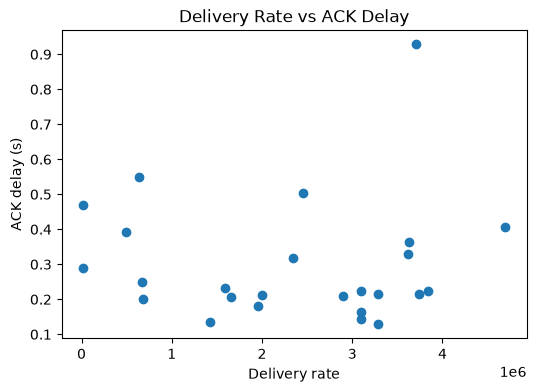

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.scatter(
    chunk_delivery["delivery_rate"],
    chunk_delivery["ack_delay_s"]
)
plt.xlabel("Delivery rate")
plt.ylabel("ACK delay (s)")
plt.title("Delivery Rate vs ACK Delay")
plt.show()

In [14]:
pearson_corr = chunk_delivery[
    ["delivery_rate", "ack_delay_s"]
].corr(method="pearson")

spearman_corr = chunk_delivery[
    ["delivery_rate", "ack_delay_s"]
].corr(method="spearman")

print("Pearson correlation")
display(pearson_corr)

print("Spearman correlation")
display(spearman_corr)

Pearson correlation


,delivery_rate,ack_delay_s
delivery_rate,1.00000,0.01362
ack_delay_s,0.01362,1.00000


Spearman correlation


,delivery_rate,ack_delay_s
delivery_rate,1.000000,-0.037543
ack_delay_s,-0.037543,1.000000


In [15]:
chunk_delivery["estimated_transfer_s"] = (
    chunk_delivery["size"]
    / chunk_delivery["delivery_rate"]
)

chunk_delivery[
    [
        "size",
        "delivery_rate",
        "estimated_transfer_s",
        "ack_delay_s"
    ]
].head(10)

,size,delivery_rate,estimated_transfer_s,ack_delay_s
0,579932,669806,0.865821,0.250
1,475807,2900000,0.164071,0.208
2,269778,3839571,0.070263,0.224
3,322657,680066,0.474450,0.201
4,209792,3281804,0.063926,0.128
5,490962,3281804,0.149601,0.216
6,819421,3615306,0.226653,0.328
7,448318,1995554,0.224658,0.211
8,195146,3735189,0.052245,0.216
9,251885,1428030,0.176386,0.135


In [16]:
print(
    chunk_delivery[
        ["estimated_transfer_s", "ack_delay_s"]
    ].corr(method="pearson")
)

print(
    chunk_delivery[
        ["estimated_transfer_s", "ack_delay_s"]
    ].corr(method="spearman")
)

                      estimated_transfer_s  ack_delay_s
estimated_transfer_s              1.000000     0.146505
ack_delay_s                       0.146505     1.000000
                      estimated_transfer_s  ack_delay_s
estimated_transfer_s              1.000000     0.705905
ack_delay_s                       0.705905     1.000000


In [17]:
display(
    chunk_delivery[
        [
            "size",
            "delivery_rate",
            "estimated_transfer_s",
            "ack_delay_s"
        ]
    ].sort_values("estimated_transfer_s")
)

,size,delivery_rate,estimated_transfer_s,ack_delay_s
8,195146,3735189,0.052245,0.216
4,209792,3281804,0.063926,0.128
2,269778,3839571,0.070263,0.224
12,274932,3096820,0.088779,0.164
11,279419,3096820,0.090228,0.145
5,490962,3281804,0.149601,0.216
10,308023,1960511,0.157114,0.180
13,507153,3096820,0.163766,0.225
1,475807,2900000,0.164071,0.208
9,251885,1428030,0.176386,0.135


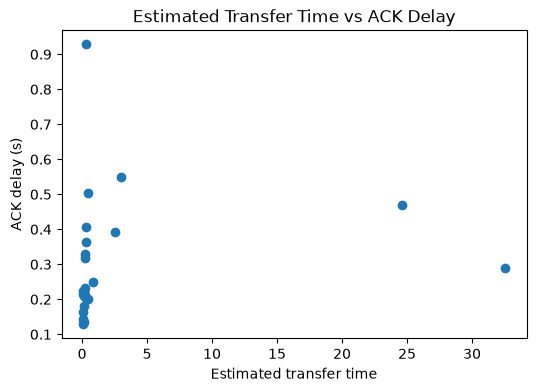

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.scatter(
    chunk_delivery["estimated_transfer_s"],
    chunk_delivery["ack_delay_s"]
)
plt.xlabel("Estimated transfer time")
plt.ylabel("ACK delay (s)")
plt.title("Estimated Transfer Time vs ACK Delay")
plt.show()


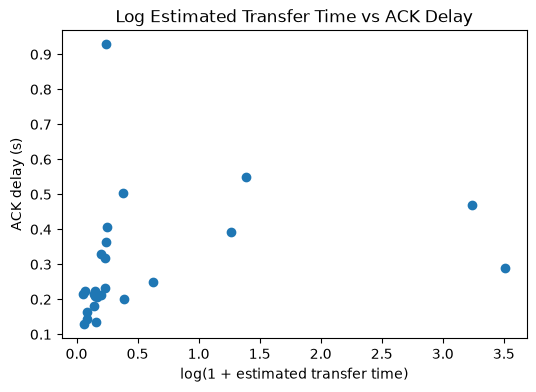

In [19]:
import numpy as np

chunk_delivery["log_estimated_transfer"] = np.log1p(
    chunk_delivery["estimated_transfer_s"]
)

plt.figure(figsize=(6, 4))
plt.scatter(
    chunk_delivery["log_estimated_transfer"],
    chunk_delivery["ack_delay_s"]
)
plt.xlabel("log(1 + estimated transfer time)")
plt.ylabel("ACK delay (s)")
plt.title("Log Estimated Transfer Time vs ACK Delay")
plt.show()

In [20]:
clean = chunk_delivery[
    chunk_delivery["estimated_transfer_s"]
    <= chunk_delivery["estimated_transfer_s"].quantile(0.90)
].copy()

print(
    clean[
        ["estimated_transfer_s", "ack_delay_s"]
    ].corr(method="pearson")
)

print(
    clean[
        ["estimated_transfer_s", "ack_delay_s"]
    ].corr(method="spearman")
)

                      estimated_transfer_s  ack_delay_s
estimated_transfer_s              1.000000     0.220697
ack_delay_s                       0.220697     1.000000
                      estimated_transfer_s  ack_delay_s
estimated_transfer_s              1.000000     0.655182
ack_delay_s                       0.655182     1.000000


In [21]:
clean2 = chunk_delivery.nsmallest(
    23,
    "estimated_transfer_s"
)

print(
    clean2[
        ["estimated_transfer_s", "ack_delay_s"]
    ].corr(method="pearson")
)

print(
    clean2[
        ["estimated_transfer_s", "ack_delay_s"]
    ].corr(method="spearman")
)

                      estimated_transfer_s  ack_delay_s
estimated_transfer_s              1.000000     0.372264
ack_delay_s                       0.372264     1.000000
                      estimated_transfer_s  ack_delay_s
estimated_transfer_s              1.000000     0.692365
ack_delay_s                       0.692365     1.000000


In [22]:
chunk_delivery["format"].value_counts()

format
1280x720-20    25
Name: count, dtype: int64

In [23]:
reg_df = chunk_delivery.copy()

reg_df["size_mb"] = reg_df["size"] / 1_000_000
reg_df["delivery_rate_mbps"] = reg_df["delivery_rate"] / 1_000_000
reg_df["rtt_ms"] = reg_df["rtt"] / 1_000

In [24]:
print(reg_df[
    ["ack_delay_s", "size_mb", "delivery_rate_mbps", "rtt_ms"]
].describe())

print(reg_df["format"].value_counts())

       ack_delay_s    size_mb  delivery_rate_mbps     rtt_ms
count    25.000000  25.000000           25.000000   25.00000
mean      0.299560   0.611953            2.316519  127.44368
std       0.174757   0.432871            1.346360   61.57271
min       0.128000   0.195146            0.013782   99.88300
25%       0.207000   0.308023            1.428030  105.73500
50%       0.225000   0.461539            2.451245  113.76100
75%       0.364000   0.819421            3.281804  122.72400
max       0.928000   1.941828            4.697974  414.31700
format
1280x720-20    25
Name: count, dtype: int64


In [26]:
import statsmodels.formula.api as smf

In [27]:
model = smf.ols(
    "ack_delay_s ~ size_mb + delivery_rate_mbps + rtt_ms",
    data=reg_df
).fit()

robust_model = model.get_robustcov_results(cov_type="HC3")

print("Ordinary OLS:")
print(model.summary())

print("\nOLS with HC3 robust standard errors:")
print(robust_model.summary())

Ordinary OLS:
                            OLS Regression Results                            
Dep. Variable:            ack_delay_s   R-squared:                       0.573
Model:                            OLS   Adj. R-squared:                  0.512
Method:                 Least Squares   F-statistic:                     9.388
Date:                Fri, 24 Jul 2026   Prob (F-statistic):           0.000390
Time:                        14:39:42   Log-Likelihood:                 19.279
No. Observations:                  25   AIC:                            -30.56
Df Residuals:                      21   BIC:                            -25.68
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             

In [28]:
from sklearn.preprocessing import StandardScaler

cols = ["size_mb", "delivery_rate_mbps", "rtt_ms"]

reg_std = reg_df.copy()
reg_std[cols] = StandardScaler().fit_transform(reg_std[cols])

model_std = smf.ols(
    "ack_delay_s ~ size_mb + delivery_rate_mbps + rtt_ms",
    data=reg_std
).fit()

print(model_std.summary())

                            OLS Regression Results                            
Dep. Variable:            ack_delay_s   R-squared:                       0.573
Model:                            OLS   Adj. R-squared:                  0.512
Method:                 Least Squares   F-statistic:                     9.388
Date:                Fri, 24 Jul 2026   Prob (F-statistic):           0.000390
Time:                        14:57:02   Log-Likelihood:                 19.279
No. Observations:                  25   AIC:                            -30.56
Df Residuals:                      21   BIC:                            -25.68
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.2996      0

In [29]:
reg_df[
    ["size_mb", "delivery_rate_mbps", "rtt_ms"]
].corr()

,size_mb,delivery_rate_mbps,rtt_ms
size_mb,1.000000,-0.037920,-0.120926
delivery_rate_mbps,-0.037920,1.000000,-0.373691
rtt_ms,-0.120926,-0.373691,1.000000


In [30]:
influence = model.get_influence()

influence_df = reg_df[
    ["ack_delay_s", "size_mb", "delivery_rate_mbps", "rtt_ms"]
].copy()

influence_df["studentized_resid"] = influence.resid_studentized_external
influence_df["leverage"] = influence.hat_matrix_diag
influence_df["cooks_distance"] = influence.cooks_distance[0]

influence_df.sort_values(
    "cooks_distance",
    ascending=False
).head(10)

,ack_delay_s,size_mb,delivery_rate_mbps,rtt_ms,studentized_resid,leverage,cooks_distance
18,0.928,1.020695,3.704363,110.485,12.538029,0.127540,0.680847
19,0.469,0.461539,0.018775,414.317,0.301317,0.946573,0.420345
15,0.549,1.941828,0.642184,105.735,-1.115609,0.494519,0.300894
16,0.406,1.310631,4.697974,112.976,-1.404785,0.309419,0.211259
17,0.392,1.237086,0.488070,114.355,-0.417577,0.211763,0.012191
20,0.289,0.448879,0.013782,165.087,0.462247,0.170402,0.011399
4,0.128,0.209792,3.281804,131.945,-0.633991,0.097730,0.011203
14,0.364,0.989866,3.634224,115.075,-0.558561,0.118581,0.010849
24,0.504,1.123330,2.451245,108.516,0.550534,0.099622,0.008671
13,0.225,0.507153,3.096820,145.715,-0.628671,0.067587,0.007374


In [32]:
def fit_hc3(data):
    return smf.ols(
        "ack_delay_s ~ size_mb + delivery_rate_mbps + rtt_ms",
        data=data
    ).fit(cov_type="HC3")

model_all = fit_hc3(reg_df)

model_no18 = fit_hc3(
    reg_df.drop(index=18)
)

model_no19 = fit_hc3(
    reg_df.drop(index=19)
)

model_no18_19 = fit_hc3(
    reg_df.drop(index=[18, 19])
)

In [33]:
comparison = pd.DataFrame({
    "all": model_all.params,
    "remove_18": model_no18.params,
    "remove_19": model_no19.params,
    "remove_18_19": model_no18_19.params
})

comparison

,all,remove_18,remove_19,remove_18_19
Intercept,-0.044014,0.029097,0.018437,0.081096
size_mb,0.300174,0.244573,0.296660,0.241684
delivery_rate_mbps,0.020499,-0.000059,0.020189,-0.000303
rtt_ms,0.000882,0.000772,0.000363,0.000340


In [34]:
pvalues = pd.DataFrame({
    "all": model_all.pvalues,
    "remove_18": model_no18.pvalues,
    "remove_19": model_no19.pvalues,
    "remove_18_19": model_no18_19.pvalues
})

r2 = pd.Series({
    "all": model_all.rsquared,
    "remove_18": model_no18.rsquared,
    "remove_19": model_no19.rsquared,
    "remove_18_19": model_no18_19.rsquared
})

display(comparison)
display(pvalues)
display(r2)

,all,remove_18,remove_19,remove_18_19
Intercept,-0.044014,0.029097,0.018437,0.081096
size_mb,0.300174,0.244573,0.296660,0.241684
delivery_rate_mbps,0.020499,-0.000059,0.020189,-0.000303
rtt_ms,0.000882,0.000772,0.000363,0.000340


,all,remove_18,remove_19,remove_18_19
Intercept,0.701837,6.089918e-01,0.931444,4.602781e-01
size_mb,0.000559,2.408603e-15,0.000630,1.342270e-15
delivery_rate_mbps,0.440425,9.925686e-01,0.470542,9.710095e-01
rtt_ms,0.107431,7.657205e-02,0.846640,7.501044e-01


all             0.572869
remove_18       0.890117
remove_19       0.556712
remove_18_19    0.878025
dtype: float64

In [35]:
display(
    chunk_delivery.loc[
        [18, 19],
        [
            "video_ts",
            "sent_time_ns",
            "acked_time_ns",
            "ack_delay_s",
            "size",
            "delivery_rate",
            "rtt",
            "cwnd",
            "in_flight",
            "min_rtt",
            "format"
        ]
    ]
)

,video_ts,sent_time_ns,acked_time_ns,ack_delay_s,size,delivery_rate,rtt,cwnd,in_flight,min_rtt,format
18,38283204960,1548500436842000000,1548500437770000000,0.928,1020695,3704363,110485,328,0,76173,1280x720-20
19,38283385140,1548500438844000000,1548500439313000000,0.469,461539,18775,414317,231,0,76173,1280x720-20


In [36]:
reg_df["predicted_ack_delay"] = model_all.predict(reg_df)

reg_df["residual"] = (
    reg_df["ack_delay_s"]
    - reg_df["predicted_ack_delay"]
)

display(
    reg_df.loc[
        15:21,
        [
            "ack_delay_s",
            "predicted_ack_delay",
            "residual",
            "size_mb",
            "delivery_rate_mbps",
            "rtt_ms"
        ]
    ]
)

,ack_delay_s,predicted_ack_delay,residual,size_mb,delivery_rate_mbps,rtt_ms
15,0.549,0.645285,-0.096285,1.941828,0.642184,105.735
16,0.406,0.545344,-0.139344,1.310631,4.697974,112.976
17,0.392,0.438183,-0.046183,1.237086,0.488070,114.355
18,0.928,0.435748,0.492252,1.020695,3.704363,110.485
19,0.469,0.460306,0.008694,0.461539,0.018775,414.317
20,0.289,0.236603,0.052397,0.448879,0.013782,165.087
21,0.231,0.212308,0.018692,0.411281,1.587286,113.761


In [39]:
display(
    chunk_delivery.loc[
        15:21,
        [
            "video_ts",
            "ack_delay_s",
            "size",
            "delivery_rate",
            "rtt",
            "min_rtt",
            "cwnd",
            "in_flight"
        ]
    ]
)

,video_ts,ack_delay_s,size,delivery_rate,rtt,min_rtt,cwnd,in_flight
15,38282664420,0.549,1941828,642184,105735,76173,307,0
16,38282844600,0.406,1310631,4697974,112976,76173,315,0
17,38283024780,0.392,1237086,488070,114355,76173,320,0
18,38283204960,0.928,1020695,3704363,110485,76173,328,0
19,38283385140,0.469,461539,18775,414317,76173,231,0
20,38283565320,0.289,448879,13782,165087,76173,167,0
21,38283745500,0.231,411281,1587286,113761,76173,173,0


In [40]:
chunk_delivery["queueing_delay_ms"] = (
    chunk_delivery["rtt"]
    - chunk_delivery["min_rtt"]
) / 1_000

display(
    chunk_delivery.loc[
        15:21,
        [
            "ack_delay_s",
            "rtt",
            "min_rtt",
            "queueing_delay_ms",
            "delivery_rate",
            "cwnd"
        ]
    ]
)

,ack_delay_s,rtt,min_rtt,queueing_delay_ms,delivery_rate,cwnd
15,0.549,105735,76173,29.562,642184,307
16,0.406,112976,76173,36.803,4697974,315
17,0.392,114355,76173,38.182,488070,320
18,0.928,110485,76173,34.312,3704363,328
19,0.469,414317,76173,338.144,18775,231
20,0.289,165087,76173,88.914,13782,167
21,0.231,113761,76173,37.588,1587286,173


In [41]:
dynamic_df = chunk_delivery.sort_values("sent_time_ns").copy()

dynamic_df["prev_delivery_rate"] = dynamic_df["delivery_rate"].shift(1)
dynamic_df["prev_rtt"] = dynamic_df["rtt"].shift(1)
dynamic_df["prev_cwnd"] = dynamic_df["cwnd"].shift(1)

dynamic_df["delivery_rate_change"] = (
    dynamic_df["delivery_rate"]
    - dynamic_df["prev_delivery_rate"]
)

dynamic_df["rtt_change"] = (
    dynamic_df["rtt"]
    - dynamic_df["prev_rtt"]
)

dynamic_df["cwnd_change"] = (
    dynamic_df["cwnd"]
    - dynamic_df["prev_cwnd"]
)

In [42]:
dynamic_df.loc[
    15:21,
    [
        "ack_delay_s",
        "delivery_rate",
        "prev_delivery_rate",
        "delivery_rate_change",
        "rtt",
        "prev_rtt",
        "rtt_change",
        "cwnd",
        "prev_cwnd",
        "cwnd_change"
    ]
]

,ack_delay_s,delivery_rate,prev_delivery_rate,delivery_rate_change,rtt,prev_rtt,rtt_change,cwnd,prev_cwnd,cwnd_change
15,0.549,642184,3634224.0,-2992040.0,105735,115075.0,-9340.0,307,303.0,4.0
16,0.406,4697974,642184.0,4055790.0,112976,105735.0,7241.0,315,307.0,8.0
17,0.392,488070,4697974.0,-4209904.0,114355,112976.0,1379.0,320,315.0,5.0
18,0.928,3704363,488070.0,3216293.0,110485,114355.0,-3870.0,328,320.0,8.0
19,0.469,18775,3704363.0,-3685588.0,414317,110485.0,303832.0,231,328.0,-97.0
20,0.289,13782,18775.0,-4993.0,165087,414317.0,-249230.0,167,231.0,-64.0
21,0.231,1587286,13782.0,1573504.0,113761,165087.0,-51326.0,173,167.0,6.0


In [43]:
dynamic_model_df = dynamic_df.dropna().copy()

dynamic_model_df["size_mb"] = dynamic_model_df["size"] / 1_000_000
dynamic_model_df["delivery_rate_mbps"] = (
    dynamic_model_df["delivery_rate"] / 1_000_000
)
dynamic_model_df["rtt_ms"] = dynamic_model_df["rtt"] / 1_000
dynamic_model_df["delivery_rate_change_mbps"] = (
    dynamic_model_df["delivery_rate_change"] / 1_000_000
)
dynamic_model_df["rtt_change_ms"] = (
    dynamic_model_df["rtt_change"] / 1_000
)

base_model = smf.ols(
    "ack_delay_s ~ size_mb + delivery_rate_mbps + rtt_ms",
    data=dynamic_model_df
).fit(cov_type="HC3")

dynamic_model = smf.ols(
    """
    ack_delay_s ~ size_mb
                + delivery_rate_mbps
                + rtt_ms
                + delivery_rate_change_mbps
                + rtt_change_ms
                + cwnd_change
    """,
    data=dynamic_model_df
).fit(cov_type="HC3")

In [44]:
comparison = pd.DataFrame({
    "base": {
        "R2": base_model.rsquared,
        "Adj_R2": base_model.rsquared_adj,
        "AIC": base_model.aic,
        "BIC": base_model.bic
    },
    "dynamic": {
        "R2": dynamic_model.rsquared,
        "Adj_R2": dynamic_model.rsquared_adj,
        "AIC": dynamic_model.aic,
        "BIC": dynamic_model.bic
    }
})

comparison

,base,dynamic
R2,0.571528,0.617932
Adj_R2,0.507257,0.483084
AIC,-28.044893,-24.795921
BIC,-23.332678,-16.549544


## 3. Questions to answer before modelling

- What does one row represent?
- Which timestamps come from the server and which from the client?
- What identifies a session and a stream?
- When is `buffer` measured?
- How is a `rebuffer` event recorded?
- Which fields are known at prediction time?
- Are rows ordered chronologically within each session?


## 4. Reconstruct one session

After identifying the correct tables and keys, select one session and sort all its events by timestamp.

In [5]:
# Example skeleton — adapt after inspecting column names.
# session_id = ...
# sent_one = video_sent[video_sent['session_id'] == session_id].copy()
# acked_one = video_acked[video_acked['session_id'] == session_id].copy()
# buffer_one = client_buffer[client_buffer['session_id'] == session_id].copy()


## 5. Record findings

Update:
- `docs/DATA_CARD.md`
- `docs/DOMAIN_MAP.md`
- `docs/UNKNOWN_UNKNOWNS.md`
- `docs/DECISION_LOG.md`